In [ ]:
#importing Libraries 
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [ ]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()

In [ ]:
#Cleanup data
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x)else x)

In [ ]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

In [ ]:
df_US_exploded =df_DA_US.explode('job_skills')

In [ ]:
df_US_exploded

In [ ]:
df_US_exploded.dropna(subset='salary_year_avg')

In [ ]:
df_DA_US_group=df_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median'])


In [40]:
df_DA_skills=df_DA_US_group.sort_values(by='count',ascending = False).head(10).sort_values(by='median',ascending = False).head(10)

In [41]:
df_DA_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


In [ ]:
df_DA_top_pay=df_DA_US_group.sort_values(by='median',ascending = False).head(10)

In [ ]:
#Top 10 highest paying skills
df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


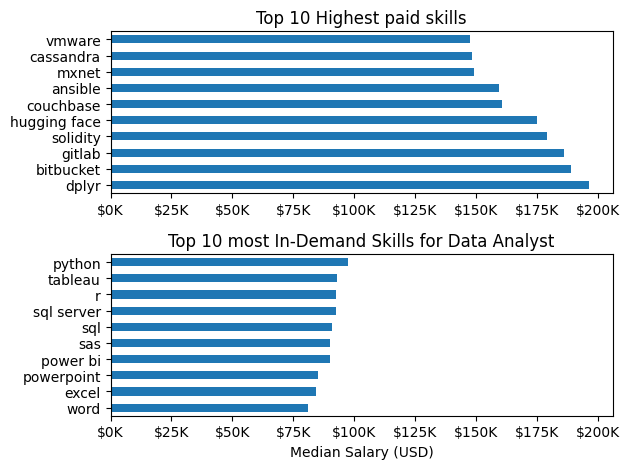

In [55]:
fig , ax = plt.subplots(2,1)
df_DA_top_pay.plot(kind = 'barh',y='median', ax= ax[0],legend =False)
#df_DA_top_pay[::-1].plot(kind = 'barh',y='median', ax= ax[0]) plot it in reverse
ax[0].invert_yaxis()
ax[0].set_title("Top 10 Highest paid skills")
ax[0].set_xlabel("")
ax[0].set_ylabel("")

df_DA_skills.plot(kind = 'barh',y ='median' ,ax = ax[1],legend =False)
ax[1].invert_yaxis()
ax[0].invert_yaxis()
ax[1].set_title("Top 10 most In-Demand Skills for Data Analyst")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_ylabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
plt.tight_layout()

